# Conditionnal vae

Project : 
-explain what a conditional vae is (algorithm type, diff with traditional vae, loss fonctions used, ...)
-train it on Fashion MNIST dataset (using pytorch)
-for each class, generate 5 new samples
-explain choices made : architecture, layer types, activations, hyper-parameters (batch size, learning rate, number of epochs, regularization weight) and the choice of the loss function
-include links of paper/articles/ressources...
-include code that helped decide on the above choices
-plot visualizations of the results (latent space (TSNE), curves of the terms of loss function during training)


## What is a conditional VAE ?

This part was written with the help of the following ressources : 


A conditional vae (cvae) differs from a traditional vae by learning on a training set with a reference variability. For instance, on the MNIST Fashion dataset, the reference variability is the type of clothe (t-shirt, trousers, shirts, etc.)

### Architecture
As said previously, the architecture of a cvae only differs from a traditional vae by adding another input for both the encoder and the decoder (reference variability, eg a class). That said, the architecture is the following : an encoder taking as input a certain type of data (in this example, the images of clothes) and the reference variability (here, the class the image belongs to). The encoder then encode the input into a latent space of much smaller dimension (in vae and cvae, it learn a latent space distribution and sample latent variable from this learnt distribution). Then, the decoder (taking as input the corresponding latent variable and reference variability) reconstructs a corrsponding output, as close as possible to the input.

#### Encoder architecture

The encoder is typically built using full connected layers or convolution layers. In this example, since we are working with images, we will use convolution layers (state of the art for vae architecture). The last layers of the encoder are two dense layers (one for the mean and one for the log of the variance). The used activations are Relu between the layers and the identity activation for the last layer.




### Usage
An useful application could be to use conditional vaes as generative algorithm. Indeed, for a given class i, the cvae learn the distribution of a latent space (with a much smaller dimension than the input one). Then, for a sampled latent variable (sampled using the distribution learnt for the class i), the user can generate an output belonging to the class i. 


### Loss function
The used training function is the same that the one used with VAEs : a two term training function, one term being the reconstruction error (MSE or BCE if normalized / binary input). The other term is a regularization term : it's a KL divergence term constraining the learnt distribution to match a given distribution (state of the art : N(0,1)). The loss function is written as follow : 
$$
\mathcal{L}_{CVAE}(\theta, \phi; x, y) = - \mathbb{E}_{q_{\phi}(z|x, y)} \left[ \log p_{\theta}(x|z, y) \right] + \beta D_{KL} \left( q_{\phi}(z|x, y) \parallel p(z|y) \right)
$$
Here, x is the input (MNIST Fashion : an image), y the reference variability (class, ex : t-shirt), z a latent variable, $q_{\phi}(z|x,y)$ learnt distribution for the encoder, $p_{\theta}(x|z,y)$ the decoder, $p_{theta}(z|y)$ a prior distribution on the latent space (given, typically N(0,1)). $\phi, \theta$ are the encoder and decoder parameters.










In [1]:
#imports
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "4"
import torch
from torch import nn
from torch.nn import functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


In [ ]:

IMAGE_SIZE = 28 # images (28x28)
INPUT_CHANNELS = 1 
NUM_CLASSES = 10   
LATENT_DIM = 32  
BATCH_SIZE = 64
EPOCHS = 40
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


transform = transforms.Compose([
    transforms.ToTensor(), 
    
    
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:



class ConditionalConvolutionalVAE(nn.Module):
    def __init__(self, input_channels, num_classes, latent_dim, img_size):
        super(ConditionalConvolutionalVAE, self).__init__()
        
        self.input_channels = input_channels
        self.num_classes = num_classes
        self.latent_dim = latent_dim
        self.img_size = img_size

   
        self.encoder_conv = nn.Sequential(
            
            nn.Conv2d(input_channels, 32, kernel_size=4, stride=2, padding=1), # Output: [32, img_size/2, img_size/2]
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # Output: [64, img_size/4, img_size/4]
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # Output: [128, img_size/8, img_size/8]
            nn.LeakyReLU(0.2)
        )
        
        self.flattened_size = 128 * (img_size // 8) * (img_size // 8)

        
        self.fc_mu = nn.Linear(self.flattened_size + num_classes, latent_dim)
        self.fc_logvar = nn.Linear(self.flattened_size + num_classes, latent_dim)

        
        self.decoder_input_fc = nn.Linear(latent_dim + num_classes, self.flattened_size)

        
        self.decoder_conv = nn.Sequential(
        
        nn.Conv2d(128, 64, kernel_size=3, padding=1),
        nn.LeakyReLU(0.2),
        nn.Upsample(scale_factor=2), # -> 8x8
        
        nn.Conv2d(64, 32, kernel_size=3, padding=1),
        nn.LeakyReLU(0.2),
        nn.Upsample(scale_factor=2), # -> 16x16
        
        nn.Conv2d(32, 16, kernel_size=3, padding=1),
        nn.LeakyReLU(0.2),
        
        nn.Upsample(size=(28, 28), mode='bilinear', align_corners=False), 
        
        nn.Conv2d(16, input_channels, kernel_size=3, padding=1),
        nn.Sigmoid()
    )
        
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, y):
      
        
        h_conv = self.encoder_conv(x) # [batch_size, 128, 4, 4]

        
        h_flat = h_conv.view(-1, self.flattened_size)

        
        h_concat = torch.cat([h_flat, y], dim=1)
        
        mu = self.fc_mu(h_concat)
        logvar = self.fc_logvar(h_concat)
        
        
        z = self.reparameterize(mu, logvar)
        
        
        z_concat = torch.cat([z, y], dim=1)

        
        h_dec_fc = self.decoder_input_fc(z_concat)
        
        
        h_dec_reshaped = h_dec_fc.view(-1, 128, self.img_size // 8, self.img_size // 8)
        
        
        recon_x = self.decoder_conv(h_dec_reshaped)
        
        return recon_x, mu, logvar

    
    def generate(self, z, y):
        
        z_concat = torch.cat([z, y], dim=1)
        h_dec_fc = self.decoder_input_fc(z_concat)
        h_dec_reshaped = h_dec_fc.view(-1, 128, self.img_size // 8, self.img_size // 8)
        return self.decoder_conv(h_dec_reshaped)



def cvae_loss_function(recon_x, x, mu, logvar):
    # BCE (Binary Cross-Entropy)
    #print(f"Shape recon_x: {recon_x.shape}")  [128, 1, 28, 28]
    #print(f"Shape x: {x.shape}")              [128, 1, 28, 28]
    BCE = F.binary_cross_entropy(recon_x.view(-1, IMAGE_SIZE*IMAGE_SIZE), x.view(-1, IMAGE_SIZE*IMAGE_SIZE), reduction='sum')
    
    # KL Divergence
    # KL = -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return BCE + KLD










Entraînement sur cuda
Train Epoch: 1 [0/60000 (0%)]	Loss: 561.029480
Train Epoch: 1 [6400/60000 (11%)]	Loss: 300.696747
Train Epoch: 1 [12800/60000 (21%)]	Loss: 268.205170
Train Epoch: 1 [19200/60000 (32%)]	Loss: 261.919556
Train Epoch: 1 [25600/60000 (43%)]	Loss: 251.797089
Train Epoch: 1 [32000/60000 (53%)]	Loss: 266.576477
Train Epoch: 1 [38400/60000 (64%)]	Loss: 252.524673
Train Epoch: 1 [44800/60000 (75%)]	Loss: 239.744675
Train Epoch: 1 [51200/60000 (85%)]	Loss: 259.285828
Train Epoch: 1 [57600/60000 (96%)]	Loss: 261.842010
====> Epoch: 1 Average loss: 269.2324
====> Test set loss: 252.4593
Train Epoch: 2 [0/60000 (0%)]	Loss: 245.829559
Train Epoch: 2 [6400/60000 (11%)]	Loss: 245.890976
Train Epoch: 2 [12800/60000 (21%)]	Loss: 252.996765
Train Epoch: 2 [19200/60000 (32%)]	Loss: 255.459427
Train Epoch: 2 [25600/60000 (43%)]	Loss: 263.007965
Train Epoch: 2 [32000/60000 (53%)]	Loss: 254.325241
Train Epoch: 2 [38400/60000 (64%)]	Loss: 241.343063
Train Epoch: 2 [44800/60000 (75%)]	Los

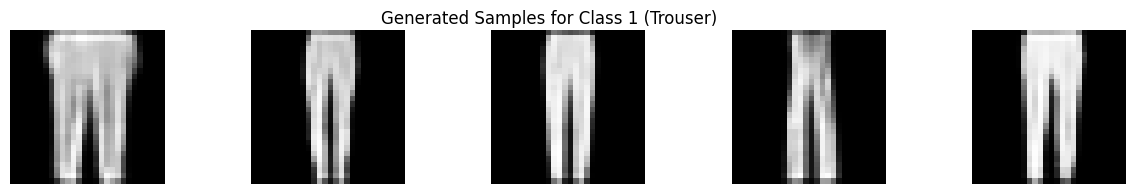

In [ ]:

model = ConditionalConvolutionalVAE(INPUT_CHANNELS, NUM_CLASSES, LATENT_DIM, IMAGE_SIZE).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


print(f"Entraînement sur {DEVICE}")
def train(epoch):
    model.train()
    train_loss = 0
    for batch_idx, (data, labels) in enumerate(train_loader):
        data = data.to(DEVICE) # [batch_size, 1, 28, 28]
        
        # onebhot encoding
        labels_onehot = F.one_hot(labels, num_classes=NUM_CLASSES).float().to(DEVICE)

        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data, labels_onehot)
        loss = cvae_loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                  f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item() / len(data):.6f}')
    
    print(f'====> Epoch: {epoch} Average loss: {train_loss / len(train_loader.dataset):.4f}')


def test(epoch):
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for i, (data, labels) in enumerate(test_loader):
            data = data.to(DEVICE)
            labels_onehot = F.one_hot(labels, num_classes=NUM_CLASSES).float().to(DEVICE)
            recon_batch, mu, logvar = model(data, labels_onehot)
            test_loss += cvae_loss_function(recon_batch, data, mu, logvar).item()

    test_loss /= len(test_loader.dataset)
    print(f'====> Test set loss: {test_loss:.4f}')

#  Génération d'images
def generate_samples(class_idx, num_samples=5):
    model.eval()
    with torch.no_grad():
        z = torch.randn(num_samples, LATENT_DIM).to(DEVICE)
        
        
        target_class = torch.full((num_samples,), class_idx, dtype=torch.long)
        
        y_conditions = F.one_hot(target_class, num_classes=NUM_CLASSES).float().to(DEVICE)
        
        samples = model.generate(z, y_conditions).cpu()
        
        
        fig, axes = plt.subplots(1, num_samples, figsize=(15, 2), squeeze=False)
        
        labels_map = {0: "T-Shirt", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat", 
                      5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle Boot"}
        
        for i, ax in enumerate(axes[0]):
            ax.imshow(samples[i].view(IMAGE_SIZE, IMAGE_SIZE), cmap='gray')
            ax.axis('off')
            
        plt.suptitle(f'Generated Samples for Class {class_idx} ({labels_map[class_idx]})')
        plt.show()
        plt.close()
if __name__ == '__main__':
    for epoch in range(1, EPOCHS + 1):
        train(epoch)
        test(epoch)
        #if epoch % 5 == 0:
        #    generate_samples(epoch)
    
    import gc

    # On libère explicitement la mémoire de l'entraînement
    if 'train_loader' in locals():
        del train_loader
    gc.collect()
    generate_samples(class_idx=1)

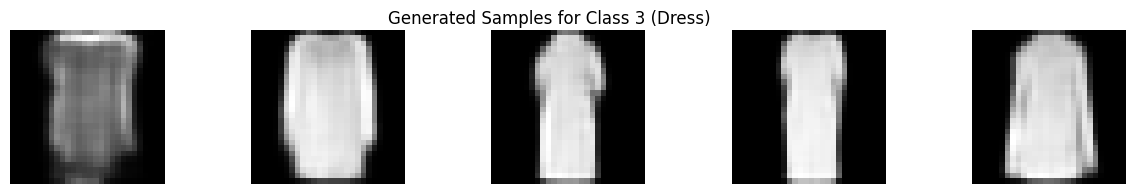

In [11]:
generate_samples(class_idx=3)